In [2]:
# Gerekli kütüphaneler
!pip install -q peft transformers accelerate

import pandas as pd
import numpy as np
import json
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Kullanılan cihaz: {device}')
print(f'CUDA mevcut mu: {torch.cuda.is_available()}')

Kullanılan cihaz: cuda
CUDA mevcut mu: True


In [3]:
# 1. Kütüphaneleri yükle
from google.colab import drive
import json
import pandas as pd
import numpy as np

drive.mount('/content/drive')

# Verileri yükle
rag_df = pd.read_csv('/content/drive/MyDrive/multihop_proje/rag_degerlendirilmis.csv')
graphrag_df = pd.read_csv('/content/drive/MyDrive/multihop_proje/graphrag_degerlendirilmis.csv')
df = pd.read_csv('/content/drive/MyDrive/multihop_proje/nlp_ozellikleri.csv')

# dogru_mu sütunlarını yeniden hesapla
from difflib import SequenceMatcher

def cevap_degerlendir(dogru, model):
    dogru = str(dogru).lower().strip()
    model = str(model).lower().strip()
    if 'bilmiyorum' in model or "i don't know" in model or 'cannot' in model:
        return False
    if dogru in model or model in dogru:
        return True
    return SequenceMatcher(None, dogru, model).ratio() >= 0.5

rag_df['dogru_mu'] = [cevap_degerlendir(r['dogru_cevap'], r['rag_cevap'])
                      for _, r in rag_df.iterrows()]
graphrag_df['dogru_mu'] = [cevap_degerlendir(r['dogru_cevap'], r['graphrag_cevap'])
                           for _, r in graphrag_df.iterrows()]

print('✅ Veriler yüklendi!')

Mounted at /content/drive
✅ Veriler yüklendi!


In [4]:
import os
dosyalar = [
    '/content/drive/MyDrive/multihop_proje/rag_degerlendirilmis.csv',
    '/content/drive/MyDrive/multihop_proje/graphrag_degerlendirilmis.csv',
    '/content/drive/MyDrive/multihop_proje/nlp_ozellikleri.csv'
]
for d in dosyalar:
    if os.path.exists(d):
        print(f"✅ {d.split('/')[-1]} mevcut")
    else:
        print(f"❌ {d.split('/')[-1]} YOK")

✅ rag_degerlendirilmis.csv mevcut
✅ graphrag_degerlendirilmis.csv mevcut
✅ nlp_ozellikleri.csv mevcut


In [ ]:
!pip install -q peft transformers accelerate

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel
from peft import LoraConfig, get_peft_model

MODEL_ADI = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_ADI)
bert_model = AutoModel.from_pretrained(MODEL_ADI)

# LoRA konfigürasyonu — torchao olmadan
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=['q_lin', 'v_lin'],
    lora_dropout=0.1,
    bias='none',
    inference_mode=False,
)

bert_with_lora = get_peft_model(bert_model, lora_config)
bert_with_lora.print_trainable_parameters()
print('✅ LoRA modeli hazır!')

In [7]:
# RAG ve GraphRAG sonuçlarını birleştir, etiket oluştur

# Her iki sistemde de yanlış olan sorular = yüksek halüsinasyon riski
# Etiket: her iki sistem de yanlışsa 1 (zor soru), ikisi de doğruysa 0

lora_df = pd.DataFrame({
    'soru': rag_df['soru'],
    'tip': rag_df['tip'],
    'ara_adim_sayisi': rag_df['ara_adim_sayisi'],
    'karmashklik_skoru': rag_df['karmashklik_skoru'],
    'dogru_cevap': rag_df['dogru_cevap'],
})

# NLP özelliklerini ekle
lora_df = lora_df.merge(
    df[['soru', 'entity_sayisi', 'fiil_sayisi',
        'clause_sayisi', 'benzersiz_entity', 'kisi_sayisi']],
    on='soru', how='left'
)

# Halüsinasyon etiketi oluştur
# 1 = Her iki sistem de yanlış yaptı (gerçekten zor)
# 0 = En az biri doğru yaptı
rag_yanlis = ~rag_df['dogru_mu']
graphrag_yanlis = ~graphrag_df['dogru_mu']

lora_df['halucinasyon_riski'] = (rag_yanlis & graphrag_yanlis).astype(int)

# Alternatif etiket: RAG yanlış mı? (daha fazla pozitif örnek)
lora_df['rag_yanlis'] = rag_yanlis.astype(int)

print(f'Toplam soru: {len(lora_df)}')
print(f'\nHalüsinasyon riski dağılımı (her iki sistem yanlış):')
print(lora_df['halucinasyon_riski'].value_counts())
print(f'\nRAG yanlış dağılımı:')
print(lora_df['rag_yanlis'].value_counts())

Toplam soru: 500

Halüsinasyon riski dağılımı (her iki sistem yanlış):
halucinasyon_riski
0    266
1    234
Name: count, dtype: int64

RAG yanlış dağılımı:
rag_yanlis
1    336
0    164
Name: count, dtype: int64


In [8]:
# Tip sütununu sayıya çevir
lora_df['tip_encoded'] = lora_df['tip'].map({
    'comparison': 0,
    'bridge_comparison': 1
})

# NaN doldur
lora_df = lora_df.fillna(0)

# Girdi özellikleri
ozellikler = [
    'ara_adim_sayisi',      # Kaç adım gerekiyor
    'karmashklik_skoru',    # Dilbilgisel karmaşıklık
    'entity_sayisi',        # Kaç varlık var
    'fiil_sayisi',          # Kaç fiil var
    'clause_sayisi',        # Kaç cümlecik var
    'benzersiz_entity',     # Kaç benzersiz varlık
    'kisi_sayisi',          # Kaç kişi adı
    'tip_encoded'           # Soru tipi
]

X = lora_df[ozellikler].values.astype(np.float32)
# HEDEF ETİKET: İki sistemin de (RAG ve GraphRAG) başarısız olduğu,
# yani yüksek halüsinasyon riski barındıran zor soruları (1) tahmin etmek.
y = lora_df['halucinasyon_riski'].values

print(f'Özellik matrisi: {X.shape}')
print(f"Seçilen etiket dağılımı: {pd.Series(y).value_counts().to_dict()}")
print(f'\nÖzellik istatistikleri:')
print(pd.DataFrame(X, columns=ozellikler).describe().round(2))

Özellik matrisi: (500, 8)
Seçilen etiket dağılımı: {0: 266, 1: 234}

Özellik istatistikleri:
       ara_adim_sayisi  karmashklik_skoru  entity_sayisi  fiil_sayisi  \
count           500.00             500.00         500.00       500.00   
mean              3.01               2.93           1.92         1.12   
std               1.01               1.77           0.85         0.83   
min               2.00               0.00           0.00         0.00   
25%               2.00               1.42           1.00         1.00   
50%               3.50               2.69           2.00         1.00   
75%               4.00               4.18           2.00         2.00   
max               5.00              10.00           5.00         5.00   

       clause_sayisi  benzersiz_entity  kisi_sayisi  tip_encoded  
count         500.00            500.00       500.00        500.0  
mean            0.50              1.92         0.76          0.5  
std             0.62              0.85         0

In [9]:
#LoRA Sınıflandırıcı (Transformer tabanlı)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train pozitif oranı: {y_train.mean()*100:.1f}%')
print(f'Test pozitif oranı: {y_test.mean()*100:.1f}%')

Train: (400, 8), Test: (100, 8)
Train pozitif oranı: 46.8%
Test pozitif oranı: 47.0%


In [10]:
# LoRA ile küçük bir transformer fine-tune et
# Soru metnini + özellikleri birlikte kullan

class HalusinasyonDataset(Dataset):
    def __init__(self, sorular, ozellikler, etiketler, tokenizer, max_len=128):
        self.sorular = sorular
        self.ozellikler = ozellikler
        self.etiketler = etiketler
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.etiketler)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.sorular[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'ozellikler': torch.tensor(self.ozellikler[idx], dtype=torch.float32),
            'etiket': torch.tensor(self.etiketler[idx], dtype=torch.long)
        }

class LoRASiniflandirici(nn.Module):
    def __init__(self, bert_model, ozellik_sayisi, num_labels=2):
        super().__init__()
        self.bert = bert_model
        hidden_size = bert_model.config.hidden_size

        # Özellik katmanı
        self.ozellik_layer = nn.Sequential(
            nn.Linear(ozellik_sayisi, 64),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # Birleştirme + sınıflandırma
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size + 64, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_labels)
        )

    def forward(self, input_ids, attention_mask, ozellikler):
        # BERT çıktısı (CLS token)
        bert_output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        cls_output = bert_output.last_hidden_state[:, 0, :]

        # NLP özellikleri
        ozellik_output = self.ozellik_layer(ozellikler)

        # Birleştir ve sınıflandır
        combined = torch.cat([cls_output, ozellik_output], dim=1)
        return self.classifier(combined)

LoRA Konfigürasyonu ve Eğitim

In [11]:
from transformers import AutoTokenizer, AutoModel

# Küçük BERT modeli (distilbert daha hızlı)
MODEL_ADI = 'distilbert-base-uncased'
print(f'Model yükleniyor: {MODEL_ADI}')

tokenizer = AutoTokenizer.from_pretrained(MODEL_ADI)
bert_model = AutoModel.from_pretrained(MODEL_ADI)

# LoRA konfigürasyonu
lora_config = LoraConfig(
    r=8,                    # Rank — düşük = az parametre
    lora_alpha=16,          # Ölçekleme faktörü
    target_modules=['q_lin', 'v_lin'],  # DistilBERT attention katmanları
    lora_dropout=0.1,
    bias='none',
)

# LoRA'yı modele uygula
bert_with_lora = get_peft_model(bert_model, lora_config)
bert_with_lora.print_trainable_parameters()
# Toplam parametreler vs eğitilebilir parametreler görürsün
# LoRA sayesinde çok az parametre eğitilir!

print('✅ LoRA modeli hazır!')

Model yükleniyor: distilbert-base-uncased


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params: 147,456 || all params: 66,510,336 || trainable%: 0.2217
✅ LoRA modeli hazır!


In [12]:
# Dataset ve DataLoader oluştur
sorular_list = lora_df['soru'].tolist()
X_train_sorular = [sorular_list[i] for i in range(len(sorular_list))
                   if i in range(len(X_train))]

# Index bazlı böl
indices = list(range(len(lora_df)))
train_idx, test_idx = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=y
)

train_dataset = HalusinasyonDataset(
    [sorular_list[i] for i in train_idx],
    X[train_idx],
    y[train_idx],
    tokenizer
)

test_dataset = HalusinasyonDataset(
    [sorular_list[i] for i in test_idx],
    X[test_idx],
    y[test_idx],
    tokenizer
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f'Train batch sayısı: {len(train_loader)}')
print(f'Test batch sayısı: {len(test_loader)}')

Train batch sayısı: 25
Test batch sayısı: 7


In [13]:
import torch
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from peft import LoraConfig, get_peft_model

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Kullanılan cihaz: {device}')

# Model oluştur
MODEL_ADI = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_ADI)
bert_model = AutoModel.from_pretrained(MODEL_ADI)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=['q_lin', 'v_lin'],
    lora_dropout=0.1,
    bias='none',
    inference_mode=False,
)
bert_with_lora = get_peft_model(bert_model, lora_config)
bert_with_lora.print_trainable_parameters()

# Sınıflandırıcı modeli oluştur ve device'a taşı
model = LoRASiniflandirici(bert_with_lora, ozellik_sayisi=len(ozellikler))
model = model.to(device)

# Optimizer ve Scheduler
num_epochs = 10
total_steps = len(train_loader) * num_epochs

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

print('Model, optimizer ve scheduler hazır!')

Kullanılan cihaz: cuda


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params: 147,456 || all params: 66,510,336 || trainable%: 0.2217
Model, optimizer ve scheduler hazır!


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Sınıf ağırlıkları en baştan ekle
sinif_agirliklari = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
agirlık_tensor = torch.tensor(sinif_agirliklari, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=agirlık_tensor)

# Epoch sayısını artır
num_epochs = 10  # 5 yerine 10

# Her epoch'ta hem accuracy hem F1 takip et
train_kayiplar = []
test_dogruluklar = []
test_f1ler = []

print('Eğitim başlıyor...')
for epoch in range(num_epochs):
    model.train()
    toplam_kayip = 0

    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        ozellikler_batch = batch['ozellikler'].to(device)
        etiketler = batch['etiket'].to(device)

        optimizer.zero_grad()
        cikti = model(input_ids, attention_mask, ozellikler_batch)
        kayip = criterion(cikti, etiketler)
        kayip.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        toplam_kayip += kayip.item()

    ort_kayip = toplam_kayip / len(train_loader)
    train_kayiplar.append(ort_kayip)

    # Değerlendirme
    model.eval()
    tum_tahmin = []
    tum_gercek_e = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            ozellikler_batch = batch['ozellikler'].to(device)
            etiketler = batch['etiket'].to(device)

            cikti = model(input_ids, attention_mask, ozellikler_batch)
            tahminler = torch.argmax(cikti, dim=1)
            tum_tahmin.extend(tahminler.cpu().numpy())
            tum_gercek_e.extend(etiketler.cpu().numpy())

    from sklearn.metrics import f1_score, accuracy_score
    dogruluk = accuracy_score(tum_gercek_e, tum_tahmin) * 100
    f1_macro = f1_score(tum_gercek_e, tum_tahmin, average='macro')

    test_dogruluklar.append(dogruluk)
    test_f1ler.append(f1_macro)

    print(f'Epoch {epoch+1}/{num_epochs} | '
          f'Kayıp: {ort_kayip:.4f} | '
          f'Accuracy: {dogruluk:.1f}% | '
          f'Macro F1: {f1_macro:.3f}')

print('Eğitim tamamlandı!')


Eğitim başlıyor...
Epoch 1/10 | Kayıp: 0.7022 | Accuracy: 63.0% | Macro F1: 0.616
Epoch 2/10 | Kayıp: 0.6726 | Accuracy: 60.0% | Macro F1: 0.599
Epoch 3/10 | Kayıp: 0.6546 | Accuracy: 61.0% | Macro F1: 0.610
Epoch 4/10 | Kayıp: 0.6297 | Accuracy: 62.0% | Macro F1: 0.612
Epoch 5/10 | Kayıp: 0.6097 | Accuracy: 71.0% | Macro F1: 0.703
Epoch 6/10 | Kayıp: 0.5704 | Accuracy: 71.0% | Macro F1: 0.705
Epoch 7/10 | Kayıp: 0.5683 | Accuracy: 71.0% | Macro F1: 0.708
Epoch 8/10 | Kayıp: 0.5487 | Accuracy: 70.0% | Macro F1: 0.694
Epoch 9/10 | Kayıp: 0.5452 | Accuracy: 70.0% | Macro F1: 0.697
Epoch 10/10 | Kayıp: 0.5302 | Accuracy: 70.0% | Macro F1: 0.696
Eğitim tamamlandı!


Sonuçları Değerlendir ve Görselleştir

=== Sınıflandırma Raporu ===
                        precision    recall  f1-score   support

       Doğru Cevap (0)       0.69      0.77      0.73        53
Halüsinasyon Riski (1)       0.71      0.62      0.66        47

              accuracy                           0.70       100
             macro avg       0.70      0.70      0.70       100
          weighted avg       0.70      0.70      0.70       100



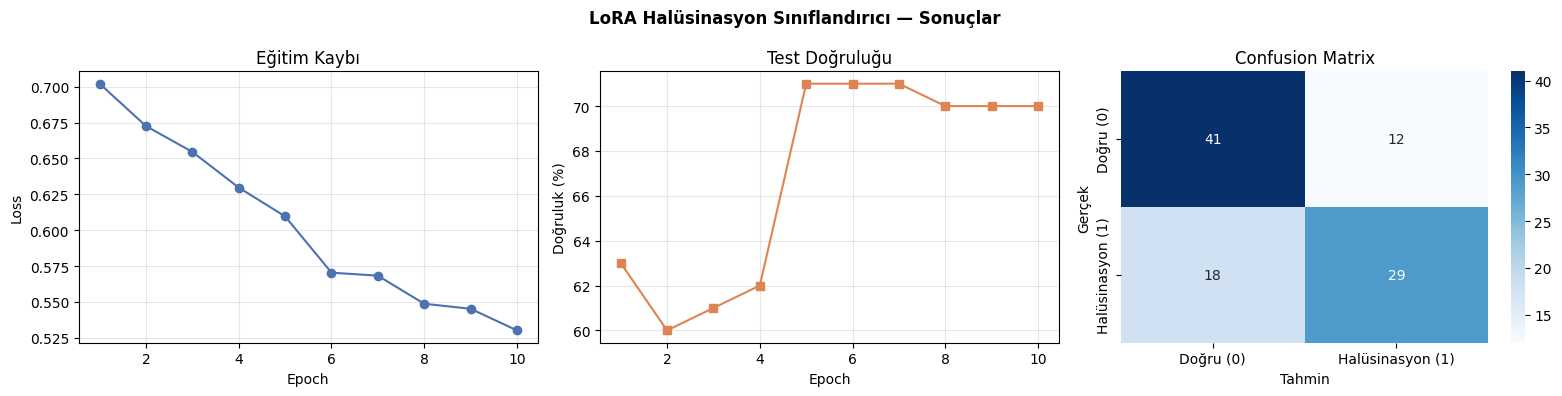

✅ Grafik kaydedildi!


'/content/drive/MyDrive/multihop_proje/lora_siniflandirici_sonuclar.png'

In [15]:
# Test seti tahminleri
model.eval()
tum_tahminler = []
tum_gercek = []
tum_olasiliklar = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        ozellikler_batch = batch['ozellikler'].to(device)
        etiketler = batch['etiket'].to(device)

        cikti = model(input_ids, attention_mask, ozellikler_batch)
        olasiliklar = torch.softmax(cikti, dim=1)
        tahminler = torch.argmax(cikti, dim=1)

        tum_tahminler.extend(tahminler.cpu().numpy())
        tum_gercek.extend(etiketler.cpu().numpy())
        tum_olasiliklar.extend(olasiliklar[:, 1].cpu().numpy())

# Classification report
print('=== Sınıflandırma Raporu ===')
print(classification_report(
    tum_gercek, tum_tahminler,
    target_names=['Doğru Cevap (0)', 'Halüsinasyon Riski (1)']
))

# Görselleştir
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('LoRA Halüsinasyon Sınıflandırıcı — Sonuçlar', fontweight='bold')

# 1. Eğitim kaybı
axes[0].plot(range(1, num_epochs+1), train_kayiplar, 'o-', color='#4C72B0')
axes[0].set_title('Eğitim Kaybı')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

# 2. Test doğruluğu
axes[1].plot(range(1, num_epochs+1), test_dogruluklar, 's-', color='#DD8452')
axes[1].set_title('Test Doğruluğu')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Doğruluk (%)')
axes[1].grid(True, alpha=0.3)

# 3. Confusion matrix
cm = confusion_matrix(tum_gercek, tum_tahminler)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Doğru (0)', 'Halüsinasyon (1)'],
            yticklabels=['Doğru (0)', 'Halüsinasyon (1)'])
axes[2].set_title('Confusion Matrix')
axes[2].set_ylabel('Gerçek')
axes[2].set_xlabel('Tahmin')

plt.tight_layout()
plt.savefig('lora_siniflandirici_sonuclar.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik kaydedildi!')

# Drive'a kaydet
import shutil
shutil.copy('lora_siniflandirici_sonuclar.png',
            '/content/drive/MyDrive/multihop_proje/lora_siniflandirici_sonuclar.png')

In [16]:
# Hücre — Dengelenmiş eğitim

from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn


# Modeli sıfırla
bert_model2 = AutoModel.from_pretrained('distilbert-base-uncased')
bert_with_lora2 = get_peft_model(bert_model2, lora_config)
model2 = LoRASiniflandirici(bert_with_lora2, ozellik_sayisi=len(ozellikler))
model2 = model2.to(device)

optimizer2 = torch.optim.AdamW(model2.parameters(), lr=2e-4, weight_decay=0.01)

scheduler2 = get_linear_schedule_with_warmup(
    optimizer2,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

# Eğitim
print('Dengelenmiş eğitim başlıyor...')
train_kayiplar2 = []
test_dogruluklar2 = []

for epoch in range(num_epochs):
    model2.train()
    toplam_kayip = 0

    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        ozellikler_batch = batch['ozellikler'].to(device)
        etiketler = batch['etiket'].to(device)

        optimizer2.zero_grad()
        cikti = model2(input_ids, attention_mask, ozellikler_batch)
        kayip = criterion(cikti, etiketler)  # Ağırlıklı loss!
        kayip.backward()
        torch.nn.utils.clip_grad_norm_(model2.parameters(), 1.0)
        optimizer2.step()
        scheduler2.step()
        toplam_kayip += kayip.item()

    ort_kayip = toplam_kayip / len(train_loader)
    train_kayiplar2.append(ort_kayip)

    # Değerlendirme
    model2.eval()
    tum_tahmin = []
    tum_gercek_e = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            ozellikler_batch = batch['ozellikler'].to(device)
            etiketler = batch['etiket'].to(device)

            cikti = model2(input_ids, attention_mask, ozellikler_batch)
            tahminler = torch.argmax(cikti, dim=1)
            tum_tahmin.extend(tahminler.cpu().numpy())
            tum_gercek_e.extend(etiketler.cpu().numpy())

    from sklearn.metrics import f1_score
    f1_macro = f1_score(tum_gercek_e, tum_tahmin, average='macro')
    dogruluk = sum(t == g for t, g in zip(tum_tahmin, tum_gercek_e)) / len(tum_tahmin) * 100
    test_dogruluklar2.append(dogruluk)

    print(f'Epoch {epoch+1}/{num_epochs} | '
          f'Kayıp: {ort_kayip:.4f} | '
          f'Accuracy: {dogruluk:.1f}% | '
          f'Macro F1: {f1_macro:.3f}')

print('✅ Dengelenmiş eğitim tamamlandı!')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Dengelenmiş eğitim başlıyor...
Epoch 1/10 | Kayıp: 0.7003 | Accuracy: 55.0% | Macro F1: 0.515
Epoch 2/10 | Kayıp: 0.6761 | Accuracy: 62.0% | Macro F1: 0.620
Epoch 3/10 | Kayıp: 0.6517 | Accuracy: 59.0% | Macro F1: 0.578
Epoch 4/10 | Kayıp: 0.6208 | Accuracy: 62.0% | Macro F1: 0.614
Epoch 5/10 | Kayıp: 0.5952 | Accuracy: 71.0% | Macro F1: 0.697
Epoch 6/10 | Kayıp: 0.5680 | Accuracy: 72.0% | Macro F1: 0.714
Epoch 7/10 | Kayıp: 0.5521 | Accuracy: 72.0% | Macro F1: 0.716
Epoch 8/10 | Kayıp: 0.5375 | Accuracy: 71.0% | Macro F1: 0.705
Epoch 9/10 | Kayıp: 0.5278 | Accuracy: 71.0% | Macro F1: 0.706
Epoch 10/10 | Kayıp: 0.5093 | Accuracy: 71.0% | Macro F1: 0.706
✅ Dengelenmiş eğitim tamamlandı!


=== Dengelenmiş Model — Sınıflandırma Raporu ===
                  precision    recall  f1-score   support

 Doğru Cevap (0)       0.71      0.77      0.74        53
Halüsinasyon (1)       0.71      0.64      0.67        47

        accuracy                           0.71       100
       macro avg       0.71      0.71      0.71       100
    weighted avg       0.71      0.71      0.71       100



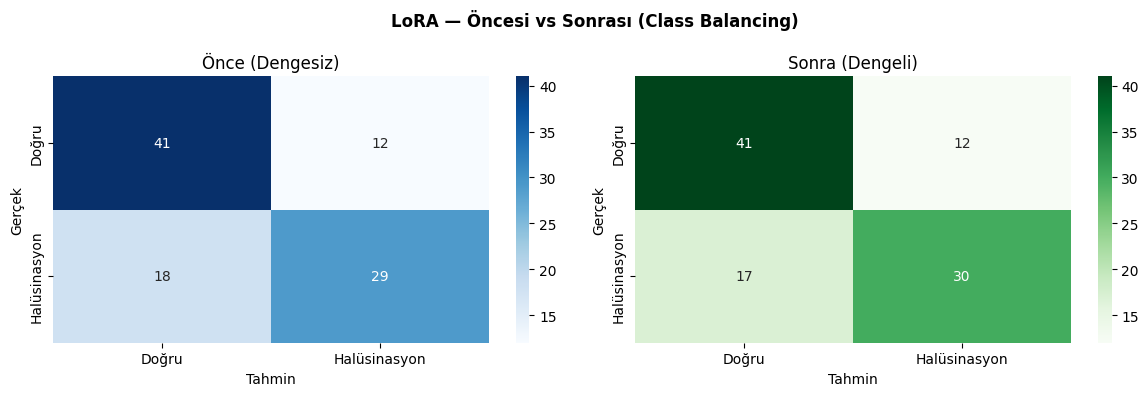

In [18]:
# Final değerlendirme
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model2.eval()
tum_tahminler2 = []
tum_gercek2 = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        ozellikler_batch = batch['ozellikler'].to(device)
        etiketler = batch['etiket'].to(device)

        cikti = model2(input_ids, attention_mask, ozellikler_batch)
        tahminler = torch.argmax(cikti, dim=1)
        tum_tahminler2.extend(tahminler.cpu().numpy())
        tum_gercek2.extend(etiketler.cpu().numpy())

print('=== Dengelenmiş Model — Sınıflandırma Raporu ===')
print(classification_report(
    tum_gercek2, tum_tahminler2,
    target_names=['Doğru Cevap (0)', 'Halüsinasyon (1)']
))

# Karşılaştırmalı confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('LoRA — Öncesi vs Sonrası (Class Balancing)', fontweight='bold')

# Önceki model
cm1 = confusion_matrix(tum_gercek, tum_tahminler)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Doğru', 'Halüsinasyon'],
            yticklabels=['Doğru', 'Halüsinasyon'])
axes[0].set_title('Önce (Dengesiz)')
axes[0].set_ylabel('Gerçek')
axes[0].set_xlabel('Tahmin')

# Yeni model
cm2 = confusion_matrix(tum_gercek2, tum_tahminler2)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Doğru', 'Halüsinasyon'],
            yticklabels=['Doğru', 'Halüsinasyon'])
axes[1].set_title('Sonra (Dengeli)')
axes[1].set_ylabel('Gerçek')
axes[1].set_xlabel('Tahmin')

plt.tight_layout()
plt.savefig('lora_dengeli_karsilastirma.png', dpi=150, bbox_inches='tight')
plt.show()



In [ ]:
# LoRA olmadan baseline karşılaştırması
# Sadece NLP özelliklerini kullanarak basit bir model

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

print("=== BASELINE KARŞILAŞTIRMA (LoRA olmadan) ===\n")

# 1. Sadece NLP özellikleriyle Logistic Regression
lr_model = LogisticRegression(class_weight='balanced', random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_f1 = f1_score(y_test, lr_pred, average='macro')

print("Logistic Regression (NLP özellikleri):")
print(classification_report(y_test, lr_pred,
      target_names=['Doğru (0)', 'Halüsinasyon (1)']))

# 2. Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_f1 = f1_score(y_test, rf_pred, average='macro')

print("Random Forest (NLP özellikleri):")
print(classification_report(y_test, rf_pred,
      target_names=['Doğru (0)', 'Halüsinasyon (1)']))

# 3. LoRA modelinin F1'i (eğitim sonrası)
lora_f1 = f1_score(tum_gercek_e, tum_tahmin, average='macro')

# Karşılaştırma tablosu
print("\n=== ÖZET KARŞILAŞTIRMA ===")
print(f"{'Model':<35} {'Macro F1':>10}")
print("-" * 47)
print(f"{'Logistic Regression (baseline)':<35} {lr_f1:>10.3f}")
print(f"{'Random Forest (baseline)':<35} {rf_f1:>10.3f}")
print(f"{'LoRA + DistilBERT (önerilen)':<35} {lora_f1:>10.3f}")

# Feature importance (Random Forest'tan)
print("\n=== EN ÖNEMLİ ÖZELLİKLER (Random Forest) ===")
onem = pd.DataFrame({
    'ozellik': ozellikler,
    'onem': rf_model.feature_importances_
}).sort_values('onem', ascending=False)
print(onem.to_string(index=False))

=== BASELINE KARŞILAŞTIRMA (LoRA olmadan) ===

Logistic Regression (NLP özellikleri):
                  precision    recall  f1-score   support

       Doğru (0)       0.68      0.72      0.70        53
Halüsinasyon (1)       0.66      0.62      0.64        47

        accuracy                           0.67       100
       macro avg       0.67      0.67      0.67       100
    weighted avg       0.67      0.67      0.67       100

Random Forest (NLP özellikleri):
                  precision    recall  f1-score   support

       Doğru (0)       0.61      0.57      0.59        53
Halüsinasyon (1)       0.55      0.60      0.57        47

        accuracy                           0.58       100
       macro avg       0.58      0.58      0.58       100
    weighted avg       0.58      0.58      0.58       100


=== ÖZET KARŞILAŞTIRMA ===
Model                                 Macro F1
-----------------------------------------------
Logistic Regression (baseline)           0.667
Random Fo

In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

# Sadece metin ile baseline
tfidf = TfidfVectorizer(max_features=500)
X_text_train = tfidf.fit_transform([sorular_list[i] for i in train_idx])
X_text_test = tfidf.transform([sorular_list[i] for i in test_idx])

lr_text = LogisticRegression(class_weight='balanced', random_state=42)
lr_text.fit(X_text_train, y_train)
lr_text_pred = lr_text.predict(X_text_test)
lr_text_f1 = f1_score(y_test, lr_text_pred, average='macro')
print(f"Sadece metin (TF-IDF): {lr_text_f1:.3f}")
print(f"Sadece NLP özellikleri: {lr_f1:.3f}")
print(f"LoRA + metin + NLP:    {lora_f1:.3f}")

Sadece metin (TF-IDF): 0.667
Sadece NLP özellikleri: 0.667
LoRA + metin + NLP:    0.706
